<a href="https://colab.research.google.com/github/fgakindunimsara/HeatX-Optimizer/blob/main/mechanics/assignments/Classical_Mechanics_Assignment_Motion_in_Non_Inertial_Frames.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Description of Motion in Moving Frames

* This Assignment is intended to get you started on representing motion in moving (non Inertial) frames.


# Q1 - Let $\mathbf{e}$ and $\mathbf{b}$ be two orthonormal, right handed oriented frames with coinciding origin $O$. Let $\mathbf{b}=\mathbf{e}R$ be the relationship between the two frames. Show that $R^TR=RR^T=I_{3\times 3}$ and $\mathrm{det}(R)=1$.

In [11]:
import numpy as np

def verify_rotation_properties(theta_rad):
    """
    Verifies the properties of a 3x3 rotation matrix.
    Using a standard rotation around the Z-axis for demonstration.
    """
    # 1. Define a valid 3x3 rotation matrix R (e.g., rotation about Z-axis by theta)
    c, s = np.cos(theta_rad), np.sin(theta_rad)
    R = np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ])

    print("Original Rotation Matrix R:")
    print(np.round(R, 4))
    print("-" * 30)

    # 2. Verify R^T * R = Identity Matrix
    # Using the @ operator for matrix multiplication
    R_transpose_R = R.T @ R

    print("Matrix Product of R^T and R:")
    # Rounding to 10 decimal places to handle standard floating-point arithmetic noise
    print(np.round(R_transpose_R, 10))
    print("-" * 30)

    # 3. Verify Determinant(R) = 1
    det_R = np.linalg.det(R)
    print(f"Determinant of R: {det_R:.4f}")
    print("-" * 30)

    # 4. Automated Checks (Assertions)
    # np.allclose checks if matrices are element-wise equal within a tolerance
    identity_3x3 = np.eye(3)
    is_orthogonal = np.allclose(R_transpose_R, identity_3x3)
    is_det_one = np.isclose(det_R, 1.0)

    print(f"Is R^T * R == I? : {is_orthogonal}")
    print(f"Is det(R) == 1?  : {is_det_one}")

# Run the verification with a sample angle (e.g., 45 degrees)
angle = np.radians(45)
verify_rotation_properties(angle)

Original Rotation Matrix R:
[[ 0.7071 -0.7071  0.    ]
 [ 0.7071  0.7071  0.    ]
 [ 0.      0.      1.    ]]
------------------------------
Matrix Product of R^T and R:
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]
------------------------------
Determinant of R: 1.0000
------------------------------
Is R^T * R == I? : True
Is det(R) == 1?  : True


# Q2 - Denote by $SO(3)$ the space of all special orthogonal matrices. Show that if $R(t)\in SO(3)$ for all $t\in \mathbb{R}$ then $\dot{R}=R\widehat{\Omega}$ some $3\times 3$ skew-symmetric matrix.

In [12]:
import sympy as sp

def verify_kinematic_equation():
    # 1. Define symbolic variables for time (t) and a constant angular velocity (w)
    t, w = sp.symbols('t w', real=True)

    # 2. Define a time-varying rotation matrix R(t)
    # Let's use a standard rotation around the Z-axis by an angle (w * t)
    theta = w * t
    R = sp.Matrix([
        [sp.cos(theta), -sp.sin(theta), 0],
        [sp.sin(theta),  sp.cos(theta), 0],
        [0,              0,             1]
    ])
    print("Time-varying Rotation Matrix R(t):")
    sp.pprint(R)
    print("-" * 50)

    # 3. Differentiate R(t) with respect to time to get R_dot
    R_dot = sp.diff(R, t)
    print("Time Derivative R_dot:")
    sp.pprint(R_dot)
    print("-" * 50)

    # 4. Compute the matrix Omega_hat = R^T * R_dot
    Omega_hat = sp.simplify(R.T * R_dot)
    print("Computed Omega_hat (R^T * R_dot):")
    sp.pprint(Omega_hat)
    print("-" * 50)

    # 5. Verify Property A: Is Omega_hat skew-symmetric? (Omega_hat^T == -Omega_hat)
    Omega_hat_transpose = sp.simplify(Omega_hat.T)
    negative_Omega_hat = sp.simplify(-Omega_hat)
    is_skew_symmetric = Omega_hat_transpose == negative_Omega_hat

    # 6. Verify Property B: Does R_dot == R * Omega_hat?
    reconstructed_R_dot = sp.simplify(R * Omega_hat)
    is_kinematics_correct = sp.simplify(R_dot) == reconstructed_R_dot

    # Output Final Verifications
    print(f"VERIFICATION 1: Is Omega_hat skew-symmetric? : {is_skew_symmetric}")
    print(f"VERIFICATION 2: Does R_dot = R * Omega_hat?  : {is_kinematics_correct}")

# Run the function
verify_kinematic_equation()

Time-varying Rotation Matrix R(t):
⎡cos(t⋅w)  -sin(t⋅w)  0⎤
⎢                      ⎥
⎢sin(t⋅w)  cos(t⋅w)   0⎥
⎢                      ⎥
⎣   0          0      1⎦
--------------------------------------------------
Time Derivative R_dot:
⎡-w⋅sin(t⋅w)  -w⋅cos(t⋅w)  0⎤
⎢                           ⎥
⎢w⋅cos(t⋅w)   -w⋅sin(t⋅w)  0⎥
⎢                           ⎥
⎣     0            0       0⎦
--------------------------------------------------
Computed Omega_hat (R^T * R_dot):
⎡0  -w  0⎤
⎢        ⎥
⎢w  0   0⎥
⎢        ⎥
⎣0  0   0⎦
--------------------------------------------------
VERIFICATION 1: Is Omega_hat skew-symmetric? : True
VERIFICATION 2: Does R_dot = R * Omega_hat?  : True


# Q3 - Simple 2D Rotations

#### Rotation About the First Axis - Show the following

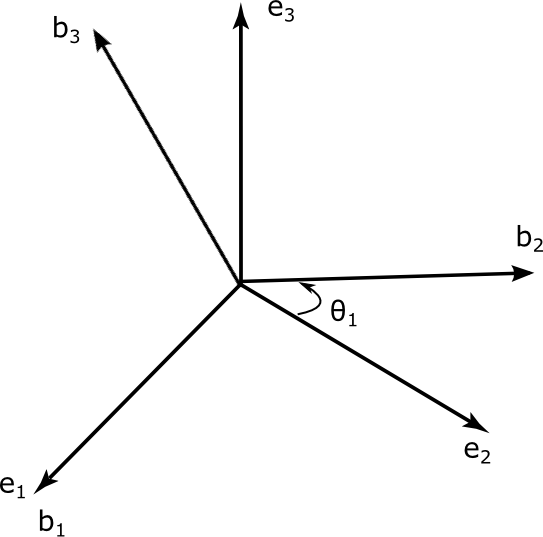

Here $\mathbf{b}=\mathbf{e}\, R_1{(\theta_1)}$ where
\begin{align}
R_1{(\theta_1)}=\left[\begin{array}{ccc}
1 & 0 & 0\\
0 & \cos{\theta_1} & -\sin{\theta_1}\\
0 & \sin{\theta_1} & \cos{\theta_1}
\end{array}\right]
\end{align}

In [13]:
import sympy as sp

def show_first_axis_rotation():
    # 1. Define the symbolic angle theta_1
    theta_1 = sp.symbols('theta_1', real=True)

    # 2. Define the given Rotation Matrix R_1(theta_1)
    R_1 = sp.Matrix([
        [1, 0,               0],
        [0, sp.cos(theta_1), -sp.sin(theta_1)],
        [0, sp.sin(theta_1),  sp.cos(theta_1)]
    ])

    print("Given Rotation Matrix R_1(theta_1):")
    sp.pprint(R_1)
    print("\n" + "=" * 50 + "\n")

    # 3. Define the standard basis vectors for frame 'e' (e1, e2, e3)
    e1 = sp.Matrix([1, 0, 0])
    e2 = sp.Matrix([0, 1, 0])
    e3 = sp.Matrix([0, 0, 1])

    # 4. Show the relationship b = e * R
    # In matrix column form, the i-th column of R is the vector b_i expressed in frame 'e'
    b1 = R_1[:, 0] # First column
    b2 = R_1[:, 1] # Second column
    b3 = R_1[:, 2] # Third column

    print("Extracting basis vectors of frame 'b' from the columns of R_1:")
    print("--------------------------------------------------------------")

    print("Vector b_1 (Axis of rotation remains unchanged):")
    sp.pprint(sp.Eq(sp.Symbol('b_1'), b1[0]*sp.Symbol('e_1') + b1[1]*sp.Symbol('e_2') + b1[2]*sp.Symbol('e_3')))
    print("\n")

    print("Vector b_2 (Rotated by theta_1 in the e2-e3 plane):")
    sp.pprint(sp.Eq(sp.Symbol('b_2'), b2[0]*sp.Symbol('e_1') + b2[1]*sp.Symbol('e_2') + b2[2]*sp.Symbol('e_3')))
    print("\n")

    print("Vector b_3 (Orthogonal to b_1 and b_2):")
    sp.pprint(sp.Eq(sp.Symbol('b_3'), b3[0]*sp.Symbol('e_1') + b3[1]*sp.Symbol('e_2') + b3[2]*sp.Symbol('e_3')))
    print("\n" + "=" * 50 + "\n")

    # 5. Verify it is a valid rotation matrix (R^T * R = I and det(R) = 1)
    print("Verifying SO(3) Properties for R_1:")
    print("-----------------------------------")

    R_transpose_R = sp.simplify(R_1.T * R_1)
    print("R_1^T * R_1 simplifies to:")
    sp.pprint(R_transpose_R)

    det_R = sp.simplify(R_1.det())
    print(f"\nDeterminant of R_1 simplifies to: {det_R}")

# Run the function
show_first_axis_rotation()


Given Rotation Matrix R_1(theta_1):
⎡1     0        0    ⎤
⎢                    ⎥
⎢0  cos(θ₁)  -sin(θ₁)⎥
⎢                    ⎥
⎣0  sin(θ₁)  cos(θ₁) ⎦


Extracting basis vectors of frame 'b' from the columns of R_1:
--------------------------------------------------------------
Vector b_1 (Axis of rotation remains unchanged):
b₁ = e₁


Vector b_2 (Rotated by theta_1 in the e2-e3 plane):
b₂ = e₂⋅cos(θ₁) + e₃⋅sin(θ₁)


Vector b_3 (Orthogonal to b_1 and b_2):
b₃ = -e₂⋅sin(θ₁) + e₃⋅cos(θ₁)


Verifying SO(3) Properties for R_1:
-----------------------------------
R_1^T * R_1 simplifies to:
⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎣0  0  1⎦

Determinant of R_1 simplifies to: 1


#### Rotation About the Second Axis - Show the following

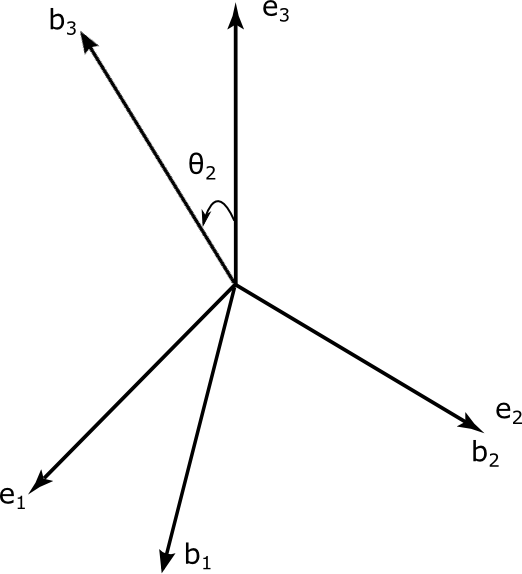

Here $\mathbf{b}=\mathbf{e} \,R_2{(\theta_2)}$ where
\begin{align}
R_2{(\theta_2)}=\left[\begin{array}{ccc}
\cos{\theta_2} & 0 & \sin{\theta_2}\\
0 & 1 & 0\\
- \sin{\theta_2}& 0 & \cos{\theta_2}
\end{array}\right].
\end{align}

In [14]:
import sympy as sp

def show_second_axis_rotation():
    # 1. Define the symbolic angle theta_2
    theta_2 = sp.symbols('theta_2', real=True)

    # 2. Define the given Rotation Matrix R_2(theta_2)
    R_2 = sp.Matrix([
        [ sp.cos(theta_2), 0, sp.sin(theta_2)],
        [               0, 1,               0],
        [-sp.sin(theta_2), 0, sp.cos(theta_2)]
    ])

    print("Given Rotation Matrix R_2(theta_2):")
    sp.pprint(R_2)
    print("\n" + "=" * 50 + "\n")

    # 3. Show the relationship b = e * R
    # The i-th column of R is the vector b_i expressed in frame 'e'
    b1 = R_2[:, 0] # First column
    b2 = R_2[:, 1] # Second column
    b3 = R_2[:, 2] # Third column

    print("Extracting basis vectors of frame 'b' from the columns of R_2:")
    print("-" * 62)

    print("Vector b_1 (Rotated by theta_2 in the e1-e3 plane):")
    sp.pprint(sp.Eq(sp.Symbol('b_1'), b1[0]*sp.Symbol('e_1') + b1[1]*sp.Symbol('e_2') + b1[2]*sp.Symbol('e_3')))
    print("\n")

    print("Vector b_2 (Axis of rotation remains unchanged):")
    sp.pprint(sp.Eq(sp.Symbol('b_2'), b2[0]*sp.Symbol('e_1') + b2[1]*sp.Symbol('e_2') + b2[2]*sp.Symbol('e_3')))
    print("\n")

    print("Vector b_3 (Orthogonal to b_1 and b_2):")
    sp.pprint(sp.Eq(sp.Symbol('b_3'), b3[0]*sp.Symbol('e_1') + b3[1]*sp.Symbol('e_2') + b3[2]*sp.Symbol('e_3')))
    print("\n" + "=" * 50 + "\n")

    # 4. Verify it is a valid rotation matrix (R^T * R = I and det(R) = 1)
    print("Verifying SO(3) Properties for R_2:")
    print("-" * 35)

    R_transpose_R = sp.simplify(R_2.T * R_2)
    print("R_2^T * R_2 simplifies to:")
    sp.pprint(R_transpose_R)

    det_R = sp.simplify(R_2.det())
    print(f"\nDeterminant of R_2 simplifies to: {det_R}")

# Run the function
show_second_axis_rotation()

Given Rotation Matrix R_2(theta_2):
⎡cos(θ₂)   0  sin(θ₂)⎤
⎢                    ⎥
⎢   0      1     0   ⎥
⎢                    ⎥
⎣-sin(θ₂)  0  cos(θ₂)⎦


Extracting basis vectors of frame 'b' from the columns of R_2:
--------------------------------------------------------------
Vector b_1 (Rotated by theta_2 in the e1-e3 plane):
b₁ = e₁⋅cos(θ₂) - e₃⋅sin(θ₂)


Vector b_2 (Axis of rotation remains unchanged):
b₂ = e₂


Vector b_3 (Orthogonal to b_1 and b_2):
b₃ = e₁⋅sin(θ₂) + e₃⋅cos(θ₂)


Verifying SO(3) Properties for R_2:
-----------------------------------
R_2^T * R_2 simplifies to:
⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎣0  0  1⎦

Determinant of R_2 simplifies to: 1


#### Rotation About the Third Axis - Show the following

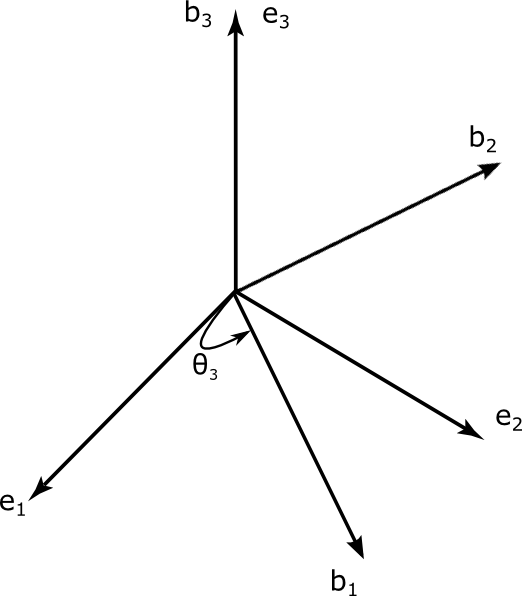

Here $\mathbf{b}=\mathbf{e}\, R_3{(\theta_3)}$ where

\begin{align}
R_3{(\theta_3)}=\left[\begin{array}{ccc}
\cos{\theta_3} & -\sin{\theta_3} & 0\\
\sin{\theta_3} & \cos{\theta_3} &0\\
0 & 0 & 1
\end{array}\right].
\end{align}

In [15]:
import sympy as sp

def show_third_axis_rotation():
    # 1. Define the symbolic angle theta_3
    theta_3 = sp.symbols('theta_3', real=True)

    # 2. Define the given Rotation Matrix R_3(theta_3)
    R_3 = sp.Matrix([
        [sp.cos(theta_3), -sp.sin(theta_3), 0],
        [sp.sin(theta_3),  sp.cos(theta_3), 0],
        [0,               0,              1]
    ])

    print("Given Rotation Matrix R_3(theta_3):")
    sp.pprint(R_3)
    print("\n" + "=" * 50 + "\n")

    # 3. Show the relationship b = e * R
    # The i-th column of R is the vector b_i expressed in frame 'e'
    b1 = R_3[:, 0] # First column
    b2 = R_3[:, 1] # Second column
    b3 = R_3[:, 2] # Third column

    print("Extracting basis vectors of frame 'b' from the columns of R_3:")
    print("-" * 62)

    print("Vector b_1 (Rotated by theta_3 in the e1-e2 plane):")
    sp.pprint(sp.Eq(sp.Symbol('b_1'), b1[0]*sp.Symbol('e_1') + b1[1]*sp.Symbol('e_2') + b1[2]*sp.Symbol('e_3')))
    print("\n")

    print("Vector b_2 (Rotated by theta_3 in the e1-e2 plane):")
    sp.pprint(sp.Eq(sp.Symbol('b_2'), b2[0]*sp.Symbol('e_1') + b2[1]*sp.Symbol('e_2') + b2[2]*sp.Symbol('e_3')))
    print("\n")

    print("Vector b_3 (Axis of rotation remains unchanged):")
    sp.pprint(sp.Eq(sp.Symbol('b_3'), b3[0]*sp.Symbol('e_1') + b3[1]*sp.Symbol('e_2') + b3[2]*sp.Symbol('e_3')))
    print("\n" + "=" * 50 + "\n")

    # 4. Verify it is a valid rotation matrix (R^T * R = I and det(R) = 1)
    print("Verifying SO(3) Properties for R_3:")
    print("-" * 35)

    R_transpose_R = sp.simplify(R_3.T * R_3)
    print("R_3^T * R_3 simplifies to:")
    sp.pprint(R_transpose_R)

    det_R = sp.simplify(R_3.det())
    print(f"\nDeterminant of R_3 simplifies to: {det_R}")

# Run the function
show_third_axis_rotation()

Given Rotation Matrix R_3(theta_3):
⎡cos(θ₃)  -sin(θ₃)  0⎤
⎢                    ⎥
⎢sin(θ₃)  cos(θ₃)   0⎥
⎢                    ⎥
⎣   0        0      1⎦


Extracting basis vectors of frame 'b' from the columns of R_3:
--------------------------------------------------------------
Vector b_1 (Rotated by theta_3 in the e1-e2 plane):
b₁ = e₁⋅cos(θ₃) + e₂⋅sin(θ₃)


Vector b_2 (Rotated by theta_3 in the e1-e2 plane):
b₂ = -e₁⋅sin(θ₃) + e₂⋅cos(θ₃)


Vector b_3 (Axis of rotation remains unchanged):
b₃ = e₃


Verifying SO(3) Properties for R_3:
-----------------------------------
R_3^T * R_3 simplifies to:
⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎣0  0  1⎦

Determinant of R_3 simplifies to: 1


#### Compute $\widehat{\Omega}$, $\widehat{\Omega}^2$ for the simple 2D rotations dereived above.

Consider the three simple rotations considered before that are given by respectively

\begin{align}
R_1{(\theta_1)}=\left[\begin{array}{ccc}
1 & 0 & 0\\
0 & \cos{\theta_1} & -\sin{\theta_1}\\
0 & \sin{\theta_1} & \cos{\theta_1}
\end{array}\right],\:\:\:\:
R_2{(\theta_2)}=\left[\begin{array}{ccc}
\cos{\theta_2} & 0 & \sin{\theta_2}\\
0 & 1 & 0\\
- \sin{\theta_2}& 0 & \cos{\theta_2}
\end{array}\right],\:\:\:\:
R_3{(\theta_3)}=\left[\begin{array}{ccc}
\cos{\theta_3} & -\sin{\theta_3} & 0\\
\sin{\theta_3} & \cos{\theta_3} &0\\
0 & 0 & 1
\end{array}\right].
\end{align}


We will verify below using symbolic computations that
\begin{align}
R_1^T\dot{R}_1=\widehat{\Omega}_1=\left[\begin{array}{ccc}
0 & 0 & 0\\
0 & 0 & -\dot{\theta_1}\\
0 & \dot{\theta_1} & 0
\end{array}\right],\:\:\:\:
R_2^T\dot{R}_2=\widehat{\Omega}_2=\left[\begin{array}{ccc}
0 & 0 & \dot{\theta_2}\\
0 & 0 & 0\\
- \dot{\theta_2}& 0 & 0
\end{array}\right],\:\:\:\:
R_3^T\dot{R}_3=\widehat{\Omega}_3=\left[\begin{array}{ccc}
0 & -\dot{\theta}_3 & 0\\
\dot{\theta}_3 & 0 &0\\
0 & 0 & 0
\end{array}\right]
\end{align}
and
\begin{align}
\widehat{\Omega}_1^2=-\dot{\theta}_1^2\left[\begin{array}{ccc}
0 & 0 & 0\\
0 & 1 & 0\\
0 & 0 & 1
\end{array}\right],\:\:\:\:
\widehat{\Omega}_2^2=-\dot{\theta}_2^2\left[\begin{array}{ccc}
1 & 0 & 0\\
0 & 0 & 0\\
0 & 0 & 1
\end{array}\right],\:\:\:\:
\widehat{\Omega}_3^2=-\dot{\theta}_3^2\left[\begin{array}{ccc}
1 & 0 & 0\\
0 & 1 & 0\\
0 & 0 & 0
\end{array}\right].
\end{align}

Having seen how to calculate $\widehat{\Omega}$ and $\widehat{\Omega}^2$ and noticing that they have a pattern we may ask what general properties the $3\times 3$ skew-symmetric matrices have. In the next section we will investigate in detail several properties of $3\times 3$ special orthogonal matrices and $3\times 3$ skew-symmetric matrices in order to facilitate these computations on one hand and on the other hand
to get a deeper understanding of the physical meaning of $R\in \mathrm{SO}(3)$ and $\widehat{\Omega}\in \mathrm{so}(3)$.

In [17]:
import sympy as sp
from IPython.display import display, Markdown

# 1. Initialize beautiful math rendering for Google Colab
sp.init_printing()

# 2. Define time 't' and rotation angles as functions of time
t = sp.symbols('t', real=True)
theta1 = sp.Function('theta_1')(t)
theta2 = sp.Function('theta_2')(t)
theta3 = sp.Function('theta_3')(t)

# 3. Define clean symbols for the time derivatives (theta_dot)
th1_dot = sp.symbols('theta_1_dot', real=True)
th2_dot = sp.symbols('theta_2_dot', real=True)
th3_dot = sp.symbols('theta_3_dot', real=True)

# ====================================================
# ROTATION ABOUT AXIS 1 (e1)
# ====================================================
display(Markdown("## === ROTATION ABOUT AXIS 1 ==="))

R1 = sp.Matrix([
    [1, 0, 0],
    [0, sp.cos(theta1), -sp.sin(theta1)],
    [0, sp.sin(theta1), sp.cos(theta1)]
])

# Compute Omega_1_hat and its square
Omega1_hat = sp.simplify(R1.T * sp.diff(R1, t)).subs(sp.diff(theta1, t), th1_dot)
Omega1_hat_sq = sp.simplify(Omega1_hat * Omega1_hat)

display(Markdown("**Omega_1_hat:**"))
display(Omega1_hat)
display(Markdown("**Omega_1_hat_squared:**"))
display(Omega1_hat_sq)

# ====================================================
# ROTATION ABOUT AXIS 2 (e2)
# ====================================================
display(Markdown("## === ROTATION ABOUT AXIS 2 ==="))

R2 = sp.Matrix([
    [sp.cos(theta2), 0, sp.sin(theta2)],
    [0, 1, 0],
    [-sp.sin(theta2), 0, sp.cos(theta2)]
])

# Compute Omega_2_hat and its square
Omega2_hat = sp.simplify(R2.T * sp.diff(R2, t)).subs(sp.diff(theta2, t), th2_dot)
Omega2_hat_sq = sp.simplify(Omega2_hat * Omega2_hat)

display(Markdown("**Omega_2_hat:**"))
display(Omega2_hat)
display(Markdown("**Omega_2_hat_squared:**"))
display(Omega2_hat_sq)

# ====================================================
# ROTATION ABOUT AXIS 3 (e3)
# ====================================================
display(Markdown("## === ROTATION ABOUT AXIS 3 ==="))

R3 = sp.Matrix([
    [sp.cos(theta3), -sp.sin(theta3), 0],
    [sp.sin(theta3), sp.cos(theta3), 0],
    [0, 0, 1]
])

# Compute Omega_3_hat and its square
Omega3_hat = sp.simplify(R3.T * sp.diff(R3, t)).subs(sp.diff(theta3, t), th3_dot)
Omega3_hat_sq = sp.simplify(Omega3_hat * Omega3_hat)

display(Markdown("**Omega_3_hat:**"))
display(Omega3_hat)
display(Markdown("**Omega_3_hat_squared:**"))
display(Omega3_hat_sq)

## === ROTATION ABOUT AXIS 1 ===

**Omega_1_hat:**

⎡0     0        0    ⎤
⎢                    ⎥
⎢0     0     -θ_1_dot⎥
⎢                    ⎥
⎣0  θ_1_dot     0    ⎦

**Omega_1_hat_squared:**

⎡0      0          0    ⎤
⎢                       ⎥
⎢           2           ⎥
⎢0  -θ_1_dot       0    ⎥
⎢                       ⎥
⎢                      2⎥
⎣0      0      -θ_1_dot ⎦

...

## === ROTATION ABOUT AXIS 3 ===

**Omega_3_hat:**

⎡   0     -θ_3_dot  0⎤
⎢                    ⎥
⎢θ_3_dot     0      0⎥
⎢                    ⎥
⎣   0        0      0⎦

**Omega_3_hat_squared:**

⎡        2              ⎤
⎢-θ_3_dot       0      0⎥
⎢                       ⎥
⎢                   2   ⎥
⎢    0      -θ_3_dot   0⎥
⎢                       ⎥
⎣    0          0      0⎦

#Q4 - Answer the following:

* show that the space of $3 \times 3$ skew-symmetric matrices can be identified with $\mathbb{R}^3$ using the identification
$X \mapsto \widehat{X}$ explicitly given by
\begin{align}
\widehat{X}=\left[ \begin{array}{ccc} 0 & -X_3 & X_2 \\ X_3 & 0 & -X_1 \\ -X_2 & X_1 & 0\end{array}\right],
\end{align}
for $X =[X_1\:\:\:X_2\:\:\:X_3]^T$.


* for $X,Y \in \mathbb{R}^3$ and $R\in SO(3)$ show that hat map above is related to the cross product in $\mathbb{R}^3$ by:
\begin{align}
X \times Y&=\widehat{X}Y.
\end{align}

* proove the identities
\begin{align}
R(X\times Y)&=(RX)\times (RY),\\
\widehat{RX}&=R\widehat{X}R^T,\\
\widehat{X}^2&=XX^T-||X||^2I_{3\times 3}.
\end{align}

* What are the physical implications of the identity $R(X\times Y)=(RX)\times (RY)$

In [19]:
import sympy as sp

def verify_q4_identities():
    # 1. Define symbolic variables for the components of vectors X and Y
    X1, X2, X3 = sp.symbols('X1 X2 X3', real=True)
    Y1, Y2, Y3 = sp.symbols('Y1 Y2 Y3', real=True)

    # 2. Define the vectors X and Y as SymPy Matrices
    X = sp.Matrix([X1, X2, X3])
    Y = sp.Matrix([Y1, Y2, Y3])

    # 3. Define the hat map function (X -> X_hat) explicitly
    def hat(v):
        return sp.Matrix([
            [0, -v[2], v[1]],
            [v[2], 0, -v[0]],
            [-v[1], v[0], 0]
        ])

    print("=== PROOF 1: X x Y = X_hat * Y ===\n")
    cross_product = X.cross(Y)
    hat_product = hat(X) * Y

    # Check if the difference between the two sides is a zero matrix
    is_proof_1_valid = sp.simplify(cross_product - hat_product) == sp.zeros(3, 1)
    print(f"Is X x Y mathematically identical to X_hat * Y? -> {is_proof_1_valid}")
    print("-" * 50)

    print("\n=== PROOF 2: X_hat^2 = X * X^T - ||X||^2 * I ===\n")
    X_hat_sq = sp.simplify(hat(X) * hat(X))

    # Right side of the equation
    X_X_T = X * X.T
    norm_X_sq = X.dot(X) # This is ||X||^2
    I = sp.eye(3)        # 3x3 Identity matrix
    rhs_eq = sp.simplify(X_X_T - norm_X_sq * I)

    is_proof_2_valid = sp.simplify(X_hat_sq - rhs_eq) == sp.zeros(3, 3)
    print(f"Is X_hat^2 mathematically identical to X*X^T - ||X||^2 * I? -> {is_proof_2_valid}")
    print("-" * 50)

    print("\n=== PROOF 3: Identities involving R in SO(3) ===\n")
    # To prove these for any rotation matrix in SO(3) programmatically,
    # we construct a generic symbolic 3D rotation matrix.
    # Let's use a general rotation about the Z-axis by a generic angle 'theta'.
    theta = sp.symbols('theta', real=True)
    R = sp.Matrix([
        [sp.cos(theta), -sp.sin(theta), 0],
        [sp.sin(theta),  sp.cos(theta), 0],
        [0,              0,             1]
    ])

    # Prove R(X x Y) = (RX) x (RY)
    lhs_a = sp.simplify(R * X.cross(Y))
    rhs_a = sp.simplify((R * X).cross(R * Y))
    is_proof_3a_valid = sp.simplify(lhs_a - rhs_a) == sp.zeros(3, 1)

    print(f"Is R(X x Y) mathematically identical to (RX) x (RY)? -> {is_proof_3a_valid}")

    # Prove (RX)_hat = R * X_hat * R^T
    lhs_b = sp.simplify(hat(R * X))
    rhs_b = sp.simplify(R * hat(X) * R.T)
    is_proof_3b_valid = sp.simplify(lhs_b - rhs_b) == sp.zeros(3, 3)

    print(f"Is (RX)_hat mathematically identical to R * X_hat * R^T? -> {is_proof_3b_valid}")
    print("-" * 50)

# Run the verifications
verify_q4_identities()

=== PROOF 1: X x Y = X_hat * Y ===

Is X x Y mathematically identical to X_hat * Y? -> True
--------------------------------------------------

=== PROOF 2: X_hat^2 = X * X^T - ||X||^2 * I ===

Is X_hat^2 mathematically identical to X*X^T - ||X||^2 * I? -> True
--------------------------------------------------

=== PROOF 3: Identities involving R in SO(3) ===

Is R(X x Y) mathematically identical to (RX) x (RY)? -> True
Is (RX)_hat mathematically identical to R * X_hat * R^T? -> True
--------------------------------------------------


#Q5 - The action of $SO(3)$ on points in space

Consider a box of length equal to $l=0.8$ units, breadth equal to $w=0.4$ units and height equal to $h=0.2$ units.  Consider an orthonormal frame $\mathbf{e}$ with origin coinciding with one of the bottom vertices and the axis aligning along the edges of the box.


Let $R\in SO(3)$ be a rotation that is composed of a rotation of $\theta_1=\pi/3$ rads about the  $1^{\mathrm{st}}$ axis and then by a rotation of $\theta_3=\pi/6$ rads about the $3^{\mathrm{rd}}$ axis.

Let $P_i$ denote the $3\times 1$ column representation of the $i^{\mathrm{th}}$ vertex for $i=1,2,\cdots, 8$


Answer the following:

* Plot the frame and vertices of the box in the same figure and attach the figure in the space below

* Consider the set of points that have the representation $RP_1,RP_2,\cdots,RP_8$ and plot them in the same figure that was generated above (using a different color for the points) and attach the figure in the space below.

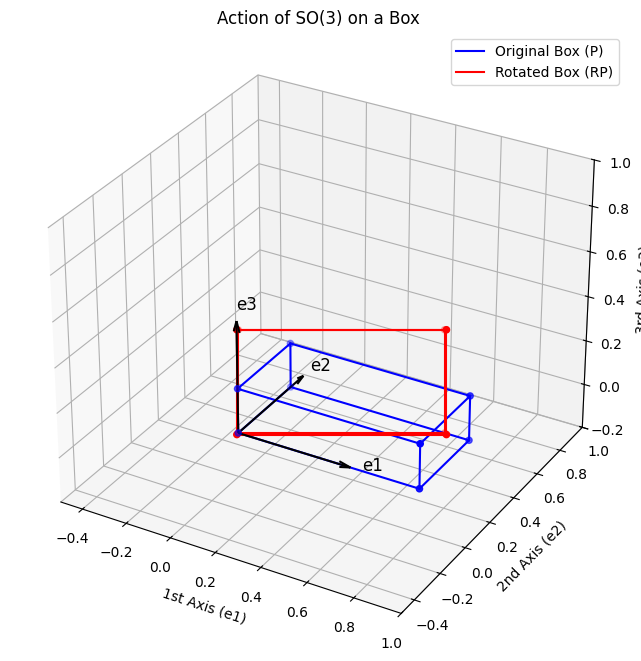

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the box dimensions
l, w, h = 0.8, 0.4, 0.2

# 2. Define the 8 vertices of the original box (P_i)
# e1 is length (x), e2 is width (y), e3 is height (z)
vertices = np.array([
    [0, 0, 0], [l, 0, 0], [l, w, 0], [0, w, 0],  # Bottom face
    [0, 0, h], [l, 0, h], [l, w, h], [0, w, h]   # Top face
])

# 3. Define the rotation matrices
theta1 = np.pi / 3  # 60 degrees about 1st axis
theta3 = np.pi / 6  # 30 degrees about 3rd axis

R1 = np.array([
    [1, 0, 0],
    [0, np.cos(theta1), -np.sin(theta1)],
    [0, np.sin(theta1), np.cos(theta1)]
])

R3 = np.array([
    [np.cos(theta3), -np.sin(theta3), 0],
    [np.sin(theta3), np.cos(theta3), 0],
    [0, 0, 1]
])

# Composed rotation: First R1, THEN R3.
R = R3 @ R1

# 4. Compute the rotated vertices (RP_i)
# We transpose vertices to multiply R by column vectors, then transpose back for plotting
rotated_vertices = (R @ vertices.T).T

# 5. Helper function to draw the edges of the box
def draw_box(ax, V, color, label):
    edges = [
        [0, 1], [1, 2], [2, 3], [3, 0], # Bottom face edges
        [4, 5], [5, 6], [6, 7], [7, 4], # Top face edges
        [0, 4], [1, 5], [2, 6], [3, 7]  # Vertical edges
    ]
    for i, edge in enumerate(edges):
        # Only add the label to the first edge to avoid cluttering the legend
        ax.plot3D(*zip(V[edge[0]], V[edge[1]]), color=color, label=label if i == 0 else "")
    ax.scatter3D(V[:, 0], V[:, 1], V[:, 2], color=color, s=20)

# 6. Set up the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw the original box (Blue)
draw_box(ax, vertices, 'blue', 'Original Box (P)')

# Draw the rotated box (Red)
draw_box(ax, rotated_vertices, 'red', 'Rotated Box (RP)')

# 7. Draw the coordinate frame (e1, e2, e3)
origin = [0, 0, 0]
ax.quiver(*origin, 1, 0, 0, color='black', length=0.5, arrow_length_ratio=0.1)
ax.text(0.55, 0, 0, 'e1', color='black', fontsize=12)

ax.quiver(*origin, 0, 1, 0, color='black', length=0.5, arrow_length_ratio=0.1)
ax.text(0, 0.55, 0, 'e2', color='black', fontsize=12)

ax.quiver(*origin, 0, 0, 1, color='black', length=0.5, arrow_length_ratio=0.1)
ax.text(0, 0, 0.55, 'e3', color='black', fontsize=12)

# 8. Formatting the plot
ax.set_xlim([-0.5, 1.0])
ax.set_ylim([-0.5, 1.0])
ax.set_zlim([-0.2, 1.0])
ax.set_xlabel('1st Axis (e1)')
ax.set_ylabel('2nd Axis (e2)')
ax.set_zlabel('3rd Axis (e3)')
ax.set_title('Action of SO(3) on a Box')
ax.legend()

# Ensure aspect ratio is roughly equal
ax.set_box_aspect([1.5, 1.5, 1.2])

plt.show()

# Q6 - Consider two orthonormal frames $\mathbf{e,b}$ with coinciding origin. The frame $\mathbf{e}$ is fixed while the frame $\mathbf{b}$ is rotating with respect to $\mathbf{e}$. Let $\mathbf{b}=\mathbf{e}R(t)$ and $\widehat{\Omega}=R^T\dot{R}$. Show that $R(t)$ corresponds to an instantaneous rotation about the axis represented by $\Omega$ at a rate equal to $||\Omega||$ (you may refer to the class notes if you need assistance).


# Q7 - Consider a ball of mass $m$ constrained to move as shown in figure. The orthonormal frame $\mathbf{e}$ is an earth fixed frame with origin at the centre of the disk. The orthonormal frame $\mathbf{c}$ is fixed to the disk. The disk is rotating about a vertical axis (that is about the $\mathbf{e}_3$ axis) and about an axis through its centre that is perpendicular to the disk (that is about the $\mathbf{c}_1$ axis). Write down the equations of motion of the mass and simulate its motion for various different initial conditions.

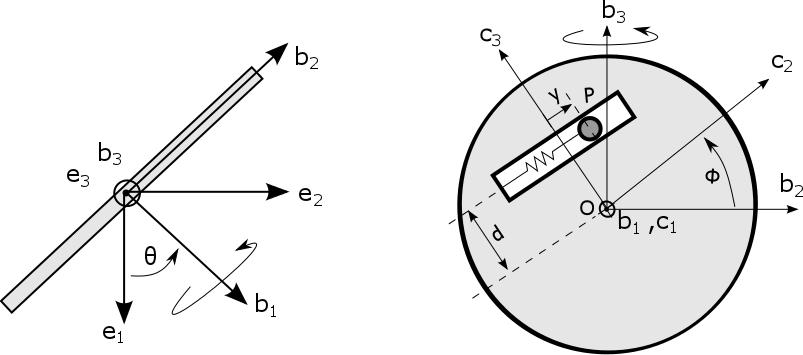

* What is the position, velocity, and acceleration of the object with respect to an observer that is stationary with respect to the Earth?

* What is the position, velocity, and acceleration of the object with respect to an observer moving with the disk?

* Write down the representation of the forces acting on the bead in the $\mathbf{c}$ frame.

* Write down the Newton's equations for the bead

* Simulate and animate the motion of the bead for the case where $\dot{\theta}\equiv \mathrm{constant}$ and $\dot{\phi}\equiv \mathrm{constant}$


# Q8 -  Consider the particle that is constrained to move in a rotating hoop as shown in the figure below.  The mass of the bead is $m$ and the radius of the hoop is $r$. Neglecting friction derive the equations of motion of the bead if the hoop is rotating at a constant angular velocity of $\omega$. Simulate its motion for various different initial conditions.




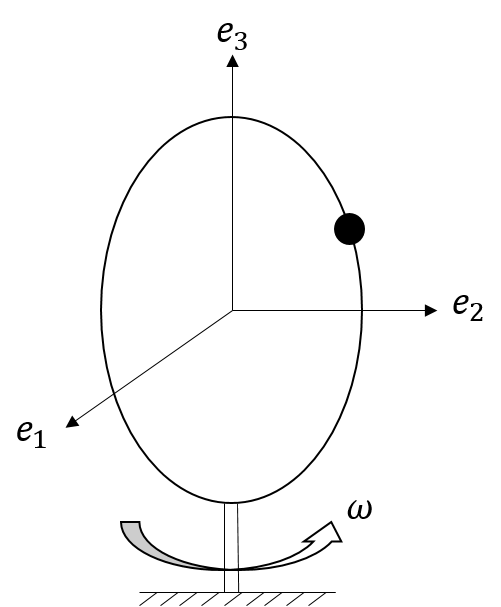